In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import json

In [47]:
all_smooth_curves

array([[ 20.80586074,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
         21.0431909 ,  20.66784539,  19.234507  ,  17.53871626,
         16.5576825 ,  16.78445158,  17.83379031,  18.68080201,
         18.42920779,  16.996556  ,  15.11635143,  13.70114276,
         13.19358478,  13.43759548,  14.01929915,  14.62080805,
         15.09135788,  15.36168771,  15.42607358,  15.36785323,
         15.29143476,  15.22200276,  15.1573284 ,  15.23107096,
         15.72659786,  16.85054095,  18.48114781,  20.13273002,
         21.17767834,  21.19262807,  20.21104097,  18.68511066,
         17.15973308,  15.93495402,  15.01734626,  14.34386452,
         13.97442781,  14.03684794,  14.51906962,  15.16353324,
         15.6034582 ,  15.63619728,  15.37343893,  15.10559247,
         15.00951232,  15.003923  ,  14.88919918,  14.58625542],
       [ 25.69126809,  25.80009414,    

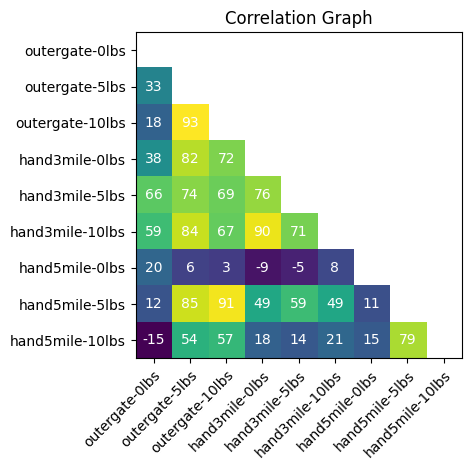

In [60]:
fig, ax = plt.subplots()
points = ["outergate", "hand3mile", "hand5mile"]
activities = ["0lbs", "5lbs", "10lbs"]
pas = []
for i in range(3):
    for j in range(3):
        pas.append(f'{points[i]}-{activities[j]}')
result = np.corrcoef(np.delete(all_smooth_curves, [0, 4, 8], axis=0))
graph = result
for i in range(9):
    for j in range(9):
        if i <= j:
            graph[i][j] = np.nan
im = ax.imshow(result)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(pas)), labels=pas,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(pas)), labels=pas)

# Loop over data dimensions and create text annotations.
for i in range(9):
    for j in range(9):
        if not(np.isnan(graph[i, j])):
            text = ax.text(j, i, int(graph[i, j]*100),
                        ha="center", va="center", color="w")

ax.set_title("Correlation Graph")
fig.tight_layout()
plt.show()


For the 9 experimental conditions(3weights for 3points), we generated 36 pairwise correlations of GP-predicted blood flow values while 20 showed moderate to strong relationships. After removing all pairwise correlation from one outlier (hand5mile 0lbs), 20 out of 28 pairwise correlation show Strong or Moderate Correlation, and 27 out of 28 pairwise show Positve Correlation. This suggests strong correlation pattern for different acupuncture points and weights for this particular activity.

Strong Correlation:
outergate 5lbs vs outergate 10lbs 0.93
outergate 5lbs vs hand3mile 0lbs 0.82
outergate 5lbs vs hand3mile 5lbs 0.74
outergate 5lbs vs hand3mile 10lbs 0.84
outergate 5lbs vs hand5mile 5lbs 0.85

outergate 10lbs vs outergate 10lbs 0.93
outergate 1lbs vs hand3mile 0lbs 0.82
outergate 5lbs vs hand3mile 5lbs 0.74
outergate 5lbs vs hand3mile 10lbs 0.84
outergate 5lbs vs hand5mile 5lbs 0.85


Conclusion:
outergate baseline: not similar to anything
outergate 0: similar to hand3mile 5lbs and hand3mile 10lbs
outergate 5: similar to outergate 10, hand3miles 0, hand3miles

In [3]:
all_smooth_curves = np.zeros((12, 60))
all_mean_curves = np.zeros((12, 60))
all_std_curves = np.zeros((12, 60))
higher_smooth_curves = np.zeros((12, 60))

c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified upper bound 3.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified lower bound 5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value fo

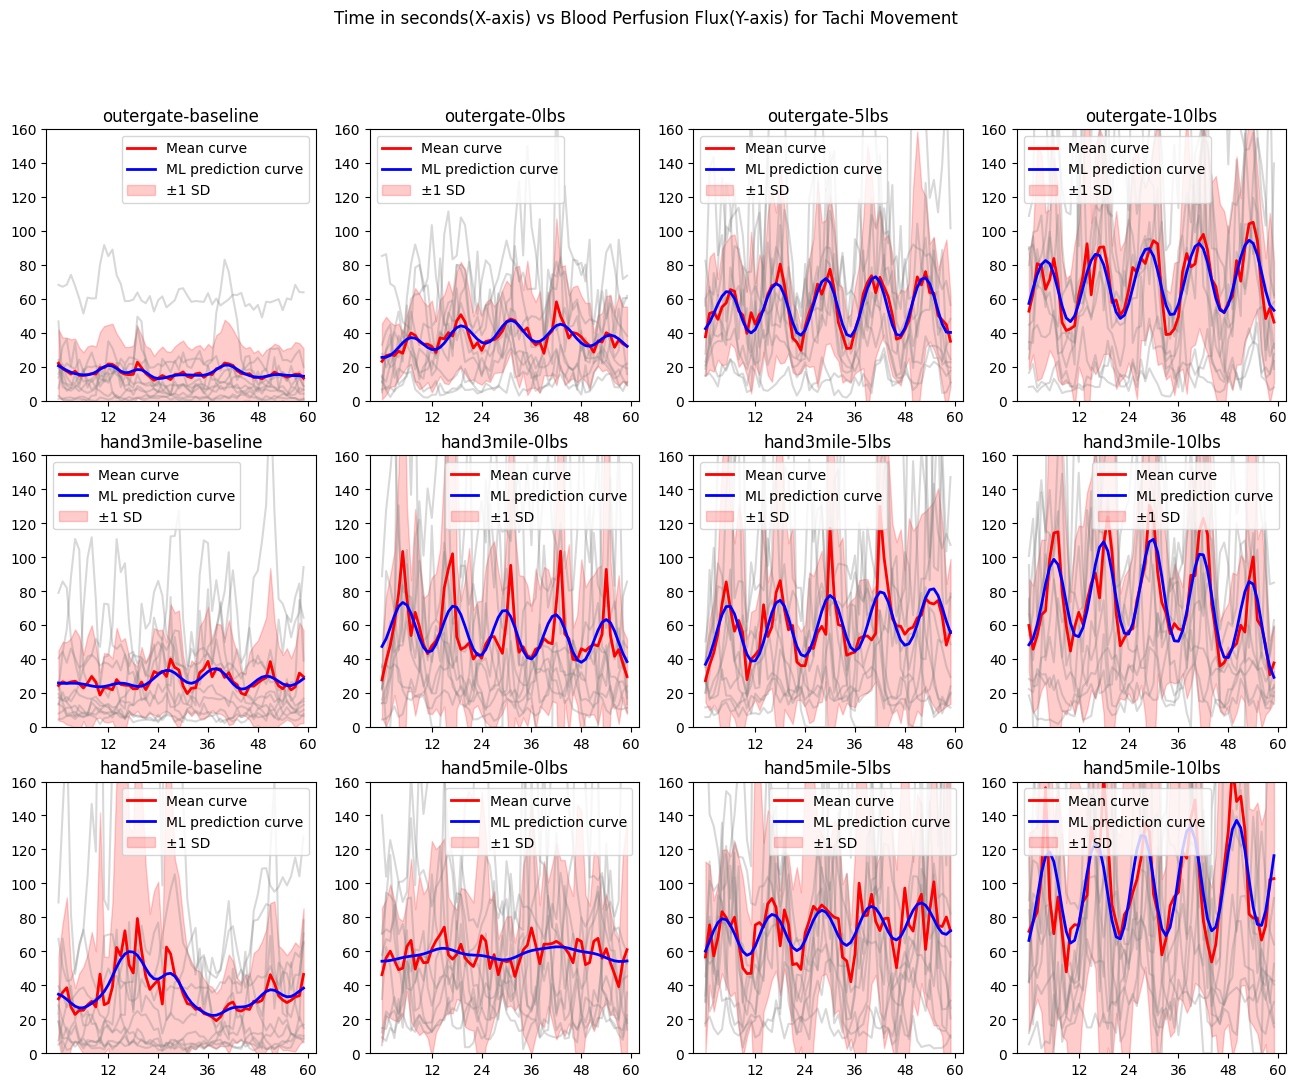

In [ ]:
from sklearn.decomposition import PCA
from scipy.interpolate import UnivariateSpline
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.gaussian_process import GaussianProcessRegressor
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, ConstantKernel



points = ["outergate", "hand3mile", "hand5mile"]
activities = ["baseline", "0lbs", "5lbs", "10lbs"]
fig, axes = plt.subplots(3, 4, figsize = (16,12))
with open("data.json", "r") as file:
    raw_data = json.load(file)
for i in range(3):
    for j in range(4):
        point_activity = []
        for a,b in raw_data.items():
                point_activity.append(b[points[i]][activities[j]])
                print(b[points])
#         #data = (data - data.mean(axis=1, keepdims=True)) / data.mean(axis=1, keepdims=True)

#         #point activity: 10 arrays of time series, shape:(10, 60)
#         data = np.array(point_activity)
#         mean_curve = data.mean(axis=0)
#         std_curve = data.std(axis=0)

#         periodicity = 12
#         kernel = (
#             ConstantKernel(1.5, constant_value_bounds=(0.5, 3.0)) *
#             RBF(length_scale=40.0, length_scale_bounds=(5, 100)) *
#             ExpSineSquared(length_scale=20.0, length_scale_bounds=(5, 100),
#                         periodicity=12, periodicity_bounds=(10, 14))
#             + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0))
#         )
#         gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)

#         X = X = np.arange(len(mean_curve)).reshape(-1, 1)
#         y = mean_curve
#         assert np.all(np.isfinite(X)), "X contains NaN or Inf"
#         assert np.all(np.isfinite(y)), "y contains NaN or Inf"

#         gp.fit(X, y)
#         y_pred, y_std = gp.predict(X, return_std=True)

#         #higher_smooth_curves[4*i+j] = smooth_curve
#         all_smooth_curves[4*i+j] = y_pred
#         # all_mean_curves[4*i+j] = mean_curve
#         # all_std_curves[4*i+j] = std_curve

#         axes[i, j].plot(data.T, color='gray', alpha=0.3)
#         axes[i, j].plot(mean_curve, color='red', linewidth=2, label='Mean curve')
#         axes[i, j].plot(y_pred, color='blue', linewidth=2, label='ML prediction curve')

#         axes[i, j].fill_between(range(len(mean_curve)), mean_curve-std_curve, mean_curve+std_curve,
#             color='red', alpha=0.2, label='±1 SD')
#         axes[i, j].legend()        
#         axes[i, j].set_xticks([12,24,36,48,60])
#         #axes[i, j].set_yticks([-1, 0, 1, 2, 3])
#         axes[i, j].set_ylim(0, 160)
#         axes[i, j].set_title(f'{points[i]}-{activities[j]}')
# fig.suptitle('Time in seconds(X-axis) vs Blood Perfusion Flux(Y-axis) for Tachi Movement')
# plt.show()

In [23]:
print(np.trapezoid(all_smooth_curves[2]))
print(np.trapezoid(all_smooth_curves[6]))
print(np.trapezoid(all_smooth_curves[10]))

3247.6636160878506
3558.471634548015
4357.224375343972


In [55]:
all_smooth_curves

array([[ 20.76494251,  19.42114952,  18.03885491,  16.91007927,
         16.13223997,  15.64229257,  15.3834171 ,  15.43165049,
         15.96917092,  17.11078106,  18.69219048,  20.19836664,
         20.96280155,  20.5708227 ,  19.19817998,  17.59861988,
         16.67212996,  16.86146505,  17.80717807,  18.57276432,
         18.33354367,  16.99093189,  15.19270835,  13.78363104,
         13.21711021,  13.40229311,  13.97208063,  14.59869237,
         15.09558948,  15.37833201,  15.44790997,  15.38767566,
         15.29289024,  15.19659909,  15.12394668,  15.22221104,
         15.75502003,  16.89545862,  18.50483602,  20.11101906,
         21.12319771,  21.15015458,  20.21883677,  18.73428604,
         17.19991755,  15.92711146,  14.97483722,  14.31496453,
         13.98943458,  14.07874082,  14.54382287,  15.14550739,
         15.56146104,  15.61438461,  15.39445321,  15.14562707,
         15.0252603 ,  14.98228244,  14.86298588,  14.60101886],
       [ 25.7065433 ,  25.81720546,  26

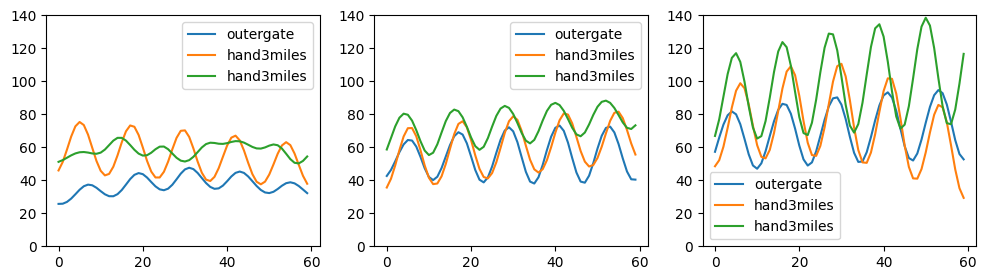

In [ ]:
fig, axes = plt.subplots(1, 3, figsize = (12, 3))
for i in range(3):
    axes[i].plot(all_smooth_curves[i + 1], label = "outergate")
    axes[i].plot(all_smooth_curves[i + 5], label = "hand3miles")
    axes[i].plot(all_smooth_curves[i + 9], label = "hand3miles")
    axes[i].legend()
    axes[i].set_ylim(0, 140)
plt.show()

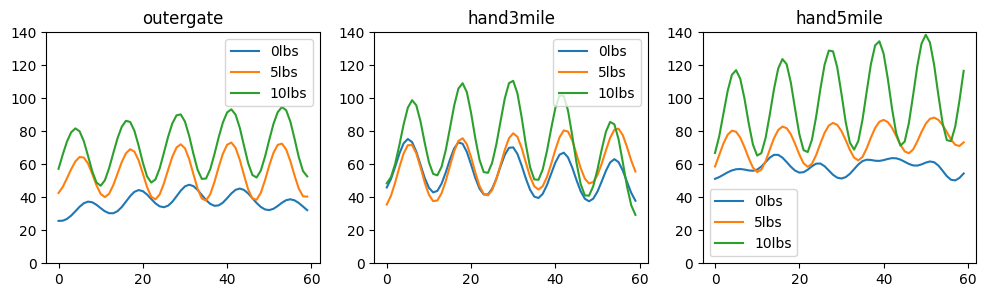

In [35]:
fig, axes = plt.subplots(1, 3, figsize = (12, 3))
for i in range(3):
    axes[i].plot(all_smooth_curves[4*i + 1], label = "0lbs")
    axes[i].plot(all_smooth_curves[4*i + 2], label = "5lbs")
    axes[i].plot(all_smooth_curves[4*i + 3], label = "10lbs")
    axes[i].legend()
    axes[i].set_ylim(0, 140)
    axes[i].set_title(f'{points[i]}')
plt.show()

In [41]:
points = ["outergate", "hand3mile", "hand5mile"]
activities = ["baseline", "0lbs", "5lbs", "10lbs"]
print("Total Blood Perfusion Flux according to Machine Learning Model Prediction are")
for i in range(3):
    for j in range(4):
        print(f'{points[i]}-{activities[j]}: ', int(np.trapezoid(all_smooth_curves[4*i+j])))

Total Blood Perfusion Flux according to Machine Learning Model Prediction are
outergate-baseline:  975
outergate-0lbs:  2196
outergate-5lbs:  3247
outergate-10lbs:  4171
hand3mile-baseline:  1603
hand3mile-0lbs:  3256
hand3mile-5lbs:  3558
hand3mile-10lbs:  4354
hand5mile-baseline:  2132
hand5mile-0lbs:  3439
hand5mile-5lbs:  4357
hand5mile-10lbs:  5800


c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified lower bound 5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__periodicity is close to the specified lower bound 9.600000000000001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal v

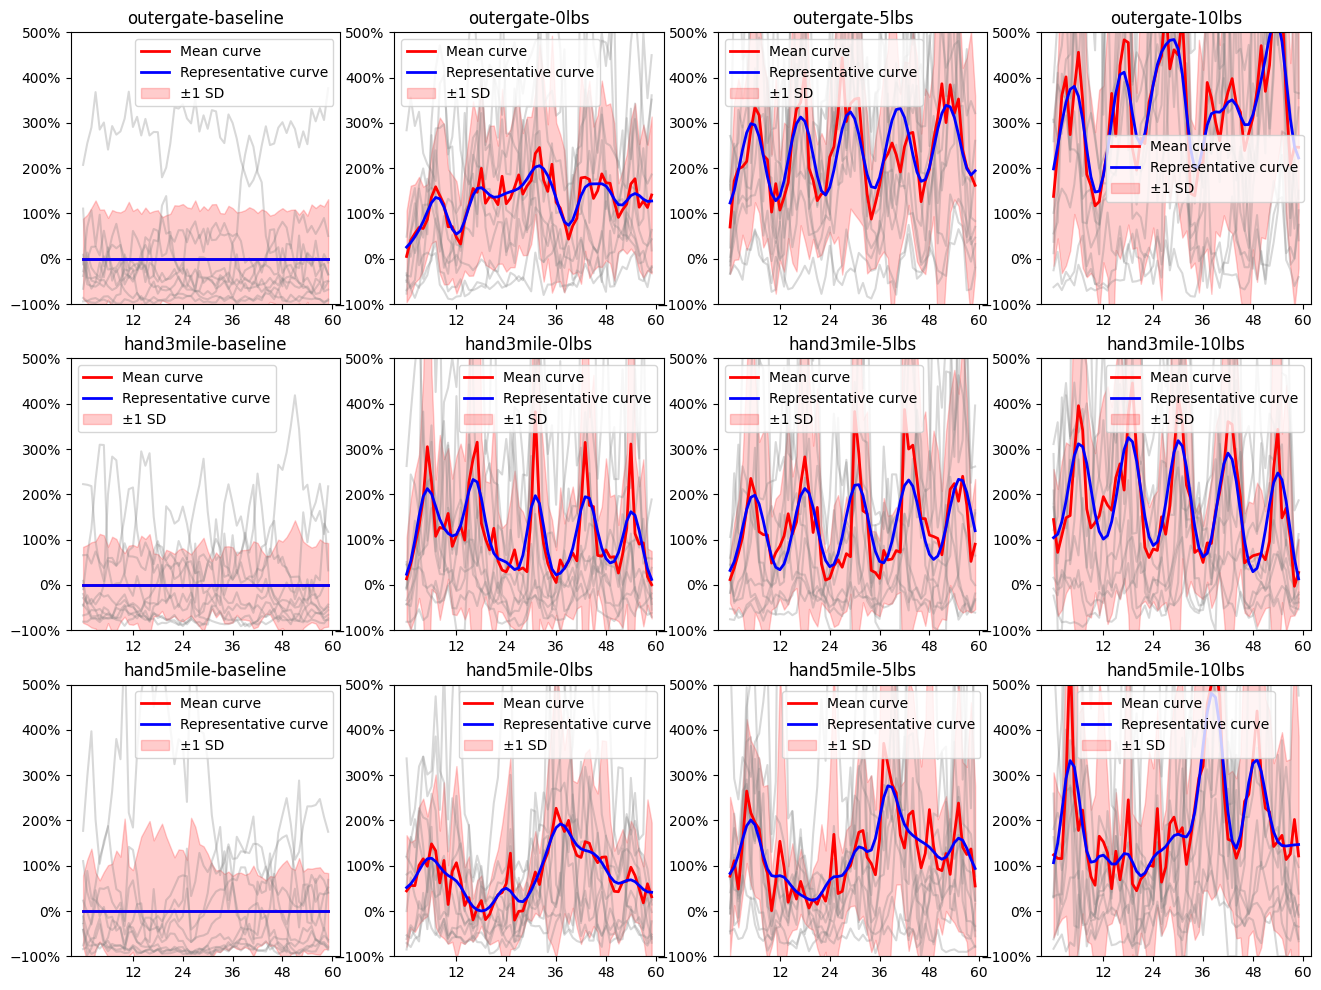

In [15]:
from sklearn.decomposition import PCA
from scipy.interpolate import UnivariateSpline
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.ticker as mtick


points = ["outergate", "hand3mile", "hand5mile"]
activities = ["baseline", "0lbs", "5lbs", "10lbs"]
fig, axes = plt.subplots(3, 4, figsize = (16,12))
with open("data.json", "r") as file:
    raw_data = json.load(file)
for i in range(3):
    for j in range(4):
        point_activity = []
        baseline = []
        for a,b in raw_data.items():
                baseline.append(b[points[i]][activities[0]])
                point_activity.append(b[points[i]][activities[j]])

        data = np.array(point_activity)
        baseline = np.array(baseline).mean(axis=0)
        data = (data - baseline) / baseline

        mean_curve = data.mean(axis=0)
        std_curve = data.std(axis=0)

        periodicity = 12
        kernel = (
            ConstantKernel(1.5, constant_value_bounds=(0.5, 3.0)) *
            RBF(length_scale=40.0, length_scale_bounds=(5, 80)) *
            ExpSineSquared(length_scale=20.0, length_scale_bounds=(5, 100),
                        periodicity=periodicity,
                        periodicity_bounds=(0.8*periodicity, 1.2*periodicity))
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 0.3))
        )
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, normalize_y=True)

        X = X = np.arange(len(mean_curve)).reshape(-1, 1)
        y = mean_curve
        gp.fit(X, y)
        y_pred, y_std = gp.predict(X, return_std=True)


        axes[i, j].plot(data.T, color='gray', alpha=0.3)
        axes[i, j].plot(mean_curve, color='red', linewidth=2, label='Mean curve')
        axes[i, j].plot(y_pred, color='blue', linewidth=2, label='Representative curve')

        axes[i, j].fill_between(range(len(mean_curve)), mean_curve-std_curve, mean_curve+std_curve,
            color='red', alpha=0.2, label='±1 SD')
        axes[i, j].legend()
        axes[i, j].set_xticks([12,24,36,48,60])
        axes[i, j].set_ylim(-1, 5)
        formatter = mtick.PercentFormatter(xmax=1.0) # xmax=1.0 indicates that 1.0 represents 100%
        axes[i, j].yaxis.set_major_formatter(formatter)

        axes[i, j].set_title(f'{points[i]}-{activities[j]}')
plt.show()